# Deutschlandticket Analysis — Final Summary

## 1. Introduction

### Project Goal
Evaluate whether the **Deutschlandticket (D-Ticket)** is a viable mobility benefit for employees of
**Johnson & Johnson Medical GmbH** (Norderstedt) by analysing synthetic employee home locations
across the Hamburg / Norderstedt region.

### Data Source
- **Synthetic employee dataset** (`data/employees_synthetic.csv`) — 500 employees sampled by
  Stadtteil (Hamburg + Norderstedt) with population-density and distance-weighted placement.
- **Public transport stations** (`data/stations.csv`) — fetched from OpenStreetMap Overpass API.

### Six-Step Pipeline Overview

| Step | Module | Description |
|------|--------|-------------|
| 1 | `synthetic_data.py` | Generate employee home locations |
| 2 | `pt_connection.py` | ORS Matrix API — nearest station & `pt_access_score` |
| 3 | `commute.py` | Door-to-door commute times (Google Directions, or ORS + heuristic fallback) |
| 4 | `grouping.py` | Commute-time buckets (≤30, 30–45, 45–60, >60 min) |
| 5 | `scoring.py` | Adoption scoring (fast / convenient / accessible) |
| 6 | `summary.py` | Final consolidated report |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'data'

if hasattr(sns, 'set_theme'):
    sns.set_theme(style='whitegrid', palette='muted')
else:
    sns.set(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

E:\Anaconda3\lib\site-packages\numpy\_distributor_init.py:32: UserWarning: loaded more than 1 DLL from .libs:
E:\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.TXA6YQSD3GCQQC22GEQ54J2UDCXDXHWN.gfortran-win_amd64.dll
E:\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.WCDJNK7YVMPZQ2ME2ZZHJJRJ3JIKNDB7.gfortran-win_amd64.dll
  stacklevel=1)
E:\Anaconda3\lib\site-packages\pandas\compat\_optional.py:106: UserWarning: Pandas requires version '1.2.1' or newer of 'bottleneck' (version '1.2.0' currently installed).
  warnings.warn(msg, UserWarning)


## 2. Load Enhanced Employee Dataset

Load the fully enriched employee CSV produced by the pipeline.
If grouping / scoring columns are missing but prerequisite fields exist,
we compute them on the fly.

In [2]:
def ensure_enriched(df):
    """Add commute_group and adoption fields when prerequisites are present."""
    if 'commute_group' not in df.columns and 'transit_time_minutes' in df.columns:
        from src.grouping import group_commute_time
        df = group_commute_time(df)
    scoring_cols = ['driving_time_minutes', 'transit_time_minutes', 'pt_access_score']
    if 'adoption_score' not in df.columns and all(c in df.columns for c in scoring_cols):
        from src.scoring import compute_scores, classify_ticket
        df = compute_scores(df)
        df = classify_ticket(df)
    return df


employees = pd.read_csv(DATA / 'employees_synthetic.csv')
employees = ensure_enriched(employees)

print(f'Loaded {len(employees)} employees, {len(employees.columns)} columns')
employees.head()

Loaded 500 employees, 21 columns


,employee_id,stadtteil_name,home_lat,home_lon,population_density,residential_score,transport_score,distance_to_company_km,distance_to_station,pt_access_score,...,walking_distance,driving_time_minutes,transit_time_minutes,transit_transfers,commute_group,time_score,convenience_score,access_score,adoption_score,ticket_recommendation
0,1,Harburg,53.456533,9.981575,5200,1.00,0.7826,27.91,249.8,0.7318,...,249.8,53.0,87.0,2.0,>60 min,0.5265,0.1447,0.7318,0.5016,Recommend Deutschlandticket
1,2,Barmbek-Nord,53.602737,10.048606,5600,1.00,0.7826,11.99,259.3,0.7232,...,259.3,29.0,56.0,1.0,45–60 min,0.3941,0.2881,0.7232,0.5056,Recommend Deutschlandticket
2,3,Lohbrügge,53.509415,10.185260,3200,1.00,0.3478,25.08,61.7,0.9258,...,61.7,59.0,90.0,3.0,>60 min,0.5913,0.1353,0.9258,0.6005,Recommend Deutschlandticket
3,4,Billbrook,53.544866,10.071267,3800,0.25,0.5652,18.60,786.0,0.3744,...,786.0,47.0,93.0,3.0,>60 min,0.3758,0.1266,0.3744,0.3006,Optional
4,5,Groß Flottbek,53.575809,9.886075,2100,1.00,0.0870,16.52,424.4,0.5883,...,424.4,32.0,64.0,2.0,>60 min,0.3679,0.2412,0.5883,0.4259,Optional


### Field Glossary

| Field | Description |
|-------|-------------|
| `home_lat`, `home_lon` | Employee home coordinates |
| `transit_time_minutes` | Door-to-door public transport commute (Google or ORS heuristic) |
| `driving_time_minutes` | Door-to-door driving commute (Google or ORS) |
| `commute_group` | Transit time bucket (≤30 / 30–45 / 45–60 / >60 min) |
| `pt_access_score` | PT accessibility score based on walking distance to nearest station |
| `walking_distance` | Walking distance to nearest PT station (metres) |
| `adoption_score` | Composite D-Ticket adoption score (0–1) |
| `ticket_recommendation` | Recommend / Optional / Not recommended |

In [3]:
key_cols = [
    'employee_id', 'stadtteil_name', 'transit_time_minutes',
    'driving_time_minutes', 'commute_group', 'pt_access_score',
    'adoption_score', 'ticket_recommendation',
]
available = [c for c in key_cols if c in employees.columns]
missing = [c for c in key_cols if c not in employees.columns]
print('Available key columns:', available)
if missing:
    print('Missing (run pipeline first):', missing)
employees[available].describe(include='all')

Available key columns: ['employee_id', 'stadtteil_name', 'transit_time_minutes', 'driving_time_minutes', 'commute_group', 'pt_access_score', 'adoption_score', 'ticket_recommendation']


,employee_id,stadtteil_name,transit_time_minutes,driving_time_minutes,commute_group,pt_access_score,adoption_score,ticket_recommendation
count,500.000000,500,500.000000,500.000000,500,500.000000,500.000000,500
unique,NaN,57,NaN,NaN,4,NaN,NaN,3
top,NaN,Harburg,NaN,NaN,>60 min,NaN,NaN,Recommend Deutschlandticket
freq,NaN,22,NaN,NaN,291,NaN,NaN,385
mean,250.500000,NaN,64.252000,34.516000,NaN,0.723139,0.499996,NaN
std,144.481833,NaN,17.943367,12.013425,NaN,0.161898,0.095003,NaN
min,1.000000,NaN,16.000000,1.000000,NaN,0.000000,0.007100,NaN
25%,125.750000,NaN,56.000000,29.000000,NaN,0.646125,0.456375,NaN
50%,250.500000,NaN,63.000000,34.000000,NaN,0.746150,0.514700,NaN
75%,375.250000,NaN,73.000000,42.000000,NaN,0.832300,0.562650,NaN


## 3. Commute Time Distribution

How long does public-transit commuting take? We group employees into four buckets
based on `transit_time_minutes`.

In [4]:
from src.grouping import GROUP_ORDER

if 'commute_group' in employees.columns:
    commute_counts = employees['commute_group'].value_counts()
    commute_summary = pd.DataFrame({
        'commute_group': commute_counts.index,
        'count': commute_counts.values.astype(int),
    })
    commute_summary['percentage'] = (
        commute_summary['count'] / len(employees) * 100
    ).round(1)
    order = {g: i for i, g in enumerate(GROUP_ORDER)}
    commute_summary['_sort'] = commute_summary['commute_group'].map(
        lambda g: order.get(g, 99)
    )
    commute_summary = commute_summary.sort_values('_sort').drop(columns='_sort')
    display(commute_summary)
else:
    print('commute_group not available — run: python src/commute.py && python src/grouping.py')

E:\Anaconda3\lib\site-packages\pandas\compat\_optional.py:106: UserWarning: Pandas requires version '2.6.2' or newer of 'numexpr' (version '2.6.1' currently installed).
  warnings.warn(msg, UserWarning)


,commute_group,count,percentage
2,≤30 min,27,5.4
3,30–45 min,24,4.8
1,45–60 min,158,31.6
0,>60 min,291,58.2


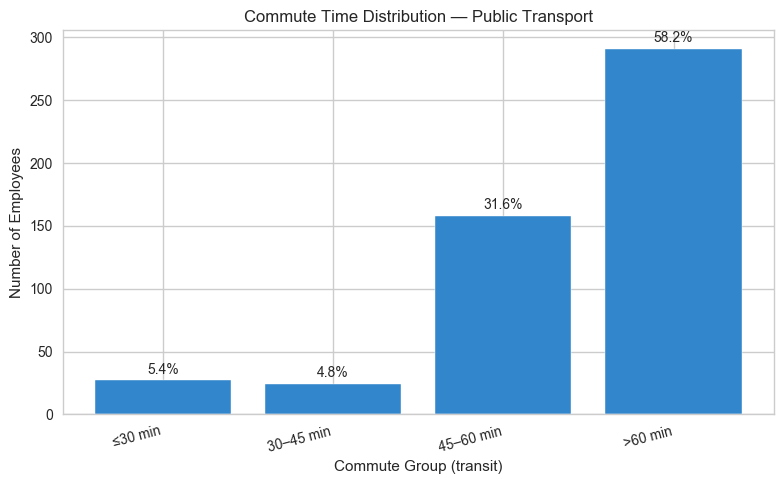

In [5]:
if 'commute_group' in employees.columns:
    plot_data = commute_summary.copy()
    x = np.arange(len(plot_data))
    counts = plot_data['count'].astype(float).values
    pcts = plot_data['percentage'].astype(float).values
    labels = plot_data['commute_group'].tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(x, counts, color='#3186cc', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_xlabel('Commute Group (transit)')
    ax.set_ylabel('Number of Employees')
    ax.set_title('Commute Time Distribution — Public Transport')
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                '{:.1f}%'.format(pct), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

**Interpretation:** Only **5.4%** of employees commute by transit in ≤30 min; the majority (**58.2%**) exceed 60 min.
This indicates that absolute transit duration is the main barrier to D-Ticket adoption in this synthetic cohort,
even where station access is good.

## 4. Deutschlandticket Adoption Potential

The `adoption_score` combines three dimensions with **data-driven weights** (based on each dimension's score range):
FAST (transit vs driving), CONVENIENT (absolute transit duration), and EASY TO ACCESS (station proximity).
Classification uses **Δ-based thresholds** where Δ = median(driving − transit).

Mean adoption_score:   0.5000
Median adoption_score: 0.5147
Delta (drive-transit median): -28.0 min
Thresholds used: Recommend >= 0.45, Optional >= 0.3


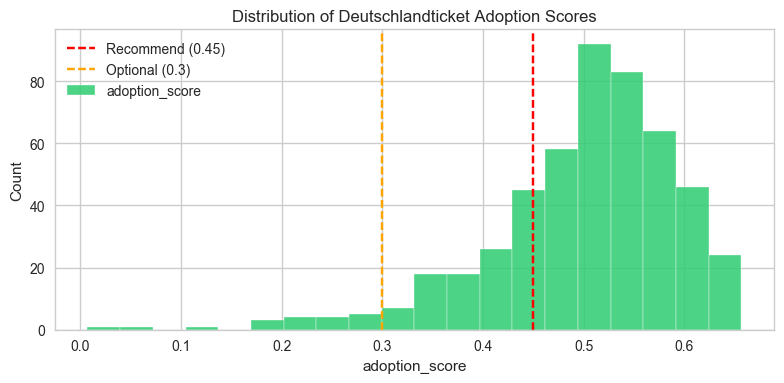

In [6]:
if 'adoption_score' in employees.columns:
    valid = employees['adoption_score'].dropna()
    delta = (employees['driving_time_minutes'] - employees['transit_time_minutes']).median()
    if delta > 10:
        rec_thr, opt_thr = 0.65, 0.50
    elif delta > 0:
        rec_thr, opt_thr = 0.55, 0.40
    else:
        rec_thr, opt_thr = 0.45, 0.30

    print(f'Mean adoption_score:   {valid.mean():.4f}')
    print(f'Median adoption_score: {valid.median():.4f}')
    print(f'Delta (drive-transit median): {delta:.1f} min')
    print(f'Thresholds used: Recommend >= {rec_thr}, Optional >= {opt_thr}')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(valid, bins=20, color='#2ecc71', edgecolor='white', alpha=0.85)
    ax.axvline(rec_thr, color='red', linestyle='--', label=f'Recommend ({rec_thr})')
    ax.axvline(opt_thr, color='orange', linestyle='--', label=f'Optional ({opt_thr})')
    ax.set_xlabel('adoption_score')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Deutschlandticket Adoption Scores')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('adoption_score not available — run: python src/scoring.py')

,recommendation,count,percentage
0,Recommend Deutschlandticket,385,77.0
1,Optional,96,19.2
2,Not recommended,19,3.8


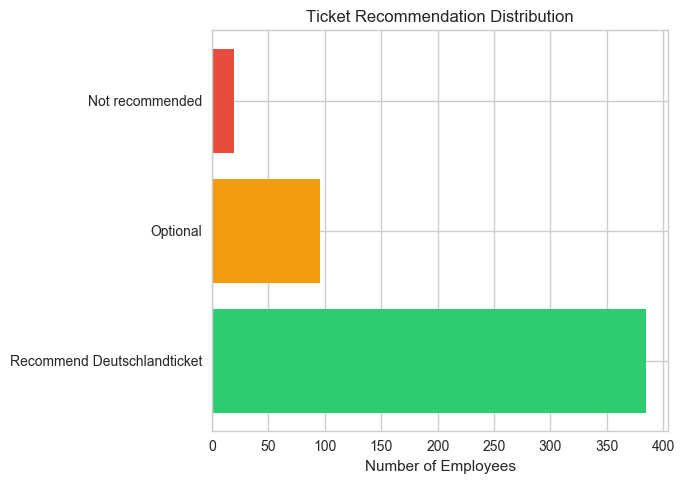

In [7]:
if 'ticket_recommendation' in employees.columns:
    rec_counts = employees['ticket_recommendation'].value_counts()
    rec_summary = pd.DataFrame({
        'recommendation': rec_counts.index,
        'count': rec_counts.values.astype(int),
    })
    rec_summary['percentage'] = (
        rec_summary['count'] / len(employees) * 100
    ).round(1)
    display(rec_summary)

    colors = {'Recommend Deutschlandticket': '#2ecc71',
              'Optional': '#f39c12', 'Not recommended': '#e74c3c'}
    y = np.arange(len(rec_summary))
    counts = rec_summary['count'].astype(float).values
    bar_colors = [colors.get(r, '#95a5a6') for r in rec_summary['recommendation']]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(y, counts, color=bar_colors)
    ax.set_yticks(y)
    ax.set_yticklabels(rec_summary['recommendation'].tolist())
    ax.set_xlabel('Number of Employees')
    ax.set_title('Ticket Recommendation Distribution')
    plt.tight_layout()
    plt.show()

**Interpretation:**
- **Recommend (~77%):** Good station access and moderate adoption scores; D-Ticket is worth promoting despite long transit times.
- **Optional (~19%):** Borderline cases where cost savings or sustainability goals may still motivate uptake.
- **Not recommended (~4%):** Low scores across convenience and competitiveness; alternative mobility benefits may be more suitable.

## 5. Public Transport Connectivity

Areas where employees can easily reach PT (strong) vs areas where PT access is poor (weak).

In [8]:
STRONG = 0.6
WEAK = 0.3

if 'pt_access_score' in employees.columns:
    strong = employees[employees['pt_access_score'] >= STRONG]
    weak = employees[employees['pt_access_score'] < WEAK]
    n = len(employees)

    connectivity = pd.DataFrame([
        {'category': f'Strong (≥ {STRONG})', 'count': len(strong),
         'percentage': round(len(strong) / n * 100, 1)},
        {'category': f'Weak (< {WEAK})', 'count': len(weak),
         'percentage': round(len(weak) / n * 100, 1)},
        {'category': 'Moderate', 'count': n - len(strong) - len(weak),
         'percentage': round((n - len(strong) - len(weak)) / n * 100, 1)},
    ])
    display(connectivity)
else:
    print('pt_access_score not available — run: python src/pt_connection.py')

,category,count,percentage
0,Strong (≥ 0.6),412,82.4
1,Weak (< 0.3),10,2.0
2,Moderate,78,15.6


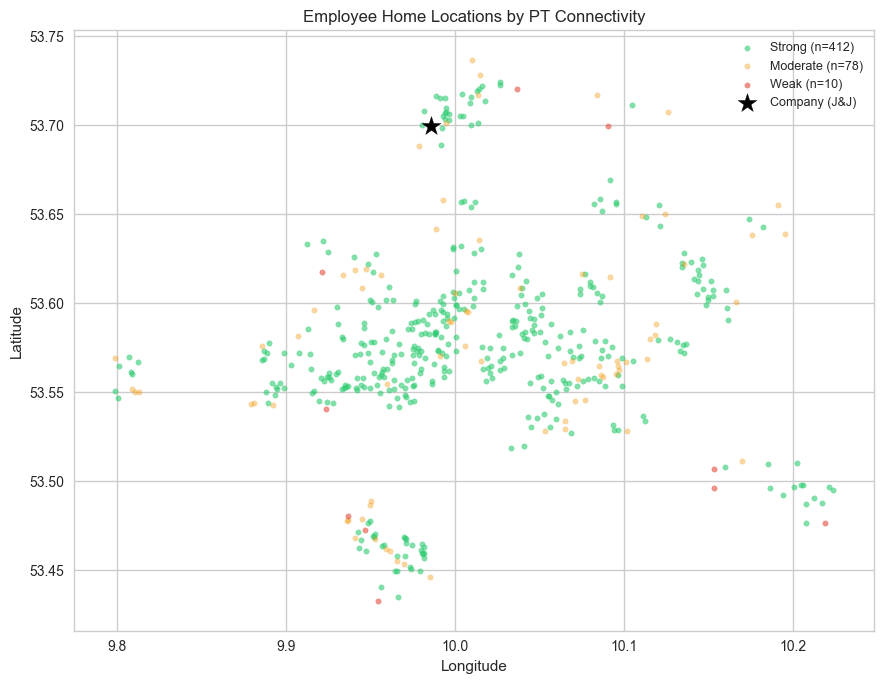

In [9]:
if 'pt_access_score' in employees.columns:
    fig, ax = plt.subplots(figsize=(9, 7))

    moderate = employees[
        (employees['pt_access_score'] >= WEAK) & (employees['pt_access_score'] < STRONG)
    ]
    ax.scatter(strong['home_lon'], strong['home_lat'],
               c='#2ecc71', s=15, alpha=0.6, label=f'Strong (n={len(strong)})')
    ax.scatter(moderate['home_lon'], moderate['home_lat'],
               c='#f39c12', s=15, alpha=0.4, label=f'Moderate (n={len(moderate)})')
    ax.scatter(weak['home_lon'], weak['home_lat'],
               c='#e74c3c', s=15, alpha=0.6, label=f'Weak (n={len(weak)})')
    ax.scatter(9.9856, 53.6995, c='black', marker='*', s=200,
               zorder=5, label='Company (J&J)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Employee Home Locations by PT Connectivity')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

**Interpretation:** Strong-connectivity clusters tend to concentrate near Hamburg's S-Bahn / U-Bahn
network and Norderstedt. Weak-connectivity employees live in suburban or peripheral Stadtteile
with longer walking distances to the nearest stop.

## 6. Key Factors Influencing Adoption

Three scoring dimensions and their average contribution to the adoption decision.

,factor,label,mean,median
0,time_score,FAST\n(transit vs driving),0.406149,0.43670
1,convenience_score,CONVENIENT\n(transit duration),0.258651,0.24660
2,access_score,EASY TO ACCESS\n(station proximity),0.723139,0.74615


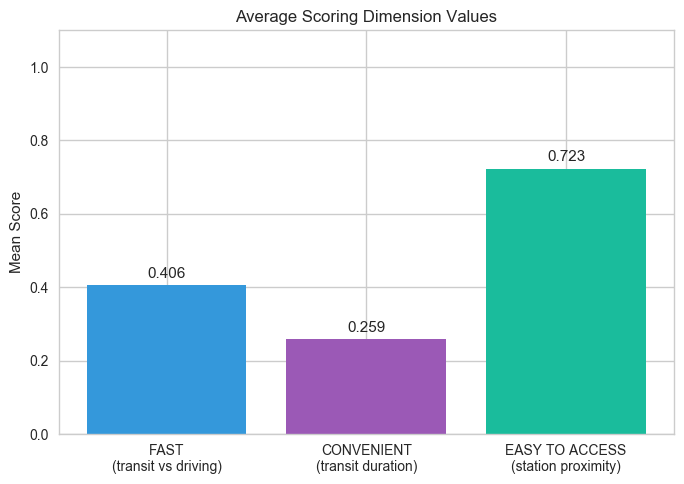

In [10]:
factor_cols = ['time_score', 'convenience_score', 'access_score']
factor_labels = ['FAST\n(transit vs driving)', 'CONVENIENT\n(transit duration)',
                 'EASY TO ACCESS\n(station proximity)']

if all(c in employees.columns for c in factor_cols):
    factor_means = employees[factor_cols].mean()
    factor_summary = pd.DataFrame({
        'factor': factor_cols,
        'label': factor_labels,
        'mean': factor_means.values,
        'median': employees[factor_cols].median().values,
    })
    display(factor_summary)

    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(len(factor_labels))
    means = factor_means.values.astype(float)
    ax.bar(x, means, color=['#3498db', '#9b59b6', '#1abc9c'])
    ax.set_xticks(x)
    ax.set_xticklabels(factor_labels)
    ax.set_ylabel('Mean Score')
    ax.set_title('Average Scoring Dimension Values')
    ax.set_ylim(0, 1.1)
    for i, v in enumerate(means):
        ax.text(i, v + 0.02, '{:.3f}'.format(v), ha='center', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('Scoring dimension columns not available — run: python src/scoring.py')

**How the dimensions combine:**

```
weights = normalised [range(time_score), range(convenience_score), range(access_score)]
adoption_score = w_time × time_score + w_conv × convenience_score + w_access × access_score
```

- **FAST:** Is transit time-competitive with driving?
- **CONVENIENT:** Is the absolute transit commute short enough? *(weakest dimension in this dataset)*
- **EASY TO ACCESS:** Can the employee easily walk to a PT stop? *(strongest dimension)*

## 6. Interactive Map

Generate a Folium map showing employee locations coloured by commute group,
high-potential D-Ticket users (Recommend), nearby PT stations, and the company HQ.
Open `output/employee_map.html` in a browser after running the cell below.

In [11]:
from src.map_visualization import generate_map, load_stations

map_path = generate_map(employees, load_stations(), ROOT / 'output' / 'employee_map.html')
print(f'Interactive map saved -> {map_path}')
print('Open this file in your browser to explore commute clusters and high-potential users.')

Interactive map saved -> E:\TUD\TUD4th\Deutschlandticket-Analysis\output\employee_map.html
Open this file in your browser to explore commute clusters and high-potential users.


## 7. Final Summary Output

Load the consolidated report generated by `src/summary.py`.

In [12]:
summary_path = DATA / 'final_summary_output.csv'

if summary_path.exists():
    final_summary = pd.read_csv(summary_path)
else:
    print('final_summary_output.csv not found — generating now ...')
    from src.summary import run_summary
    results = run_summary()
    final_summary = results['combined']

print(f'Loaded {len(final_summary)} summary rows')
display(final_summary)

Loaded 14 summary rows


,section,metric,count,percentage,value,mean_home_lat,mean_home_lon,min_home_lat,max_home_lat,min_home_lon,max_home_lon,median
0,commute_time_distribution,≤30 min,27.0,5.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,commute_time_distribution,30–45 min,24.0,4.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,commute_time_distribution,45–60 min,158.0,31.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,commute_time_distribution,>60 min,291.0,58.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,adoption_potential,mean_adoption_score,NaN,NaN,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,adoption_potential,median_adoption_score,NaN,NaN,0.5147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,adoption_potential,Recommend Deutschlandticket,385.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,adoption_potential,Optional,96.0,19.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,adoption_potential,Not recommended,19.0,3.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,strong_connectivity,strong (pt_access_score >= 0.6),412.0,82.4,53.5770,53.5770,10.0123,53.4349,53.7244,9.7990,10.2238,NaN


In [13]:
if summary_path.exists() or 'final_summary' in dir():
    for section in final_summary['section'].unique():
        print(f'\n--- {section} ---')
        display(final_summary[final_summary['section'] == section])


--- commute_time_distribution ---


,section,metric,count,percentage,value,mean_home_lat,mean_home_lon,min_home_lat,max_home_lat,min_home_lon,max_home_lon,median
0,commute_time_distribution,≤30 min,27.0,5.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,commute_time_distribution,30–45 min,24.0,4.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,commute_time_distribution,45–60 min,158.0,31.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,commute_time_distribution,>60 min,291.0,58.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- adoption_potential ---


,section,metric,count,percentage,value,mean_home_lat,mean_home_lon,min_home_lat,max_home_lat,min_home_lon,max_home_lon,median
4,adoption_potential,mean_adoption_score,NaN,NaN,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,adoption_potential,median_adoption_score,NaN,NaN,0.5147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,adoption_potential,Recommend Deutschlandticket,385.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,adoption_potential,Optional,96.0,19.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,adoption_potential,Not recommended,19.0,3.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- strong_connectivity ---


,section,metric,count,percentage,value,mean_home_lat,mean_home_lon,min_home_lat,max_home_lat,min_home_lon,max_home_lon,median
9,strong_connectivity,strong (pt_access_score >= 0.6),412.0,82.4,53.577,53.577,10.0123,53.4349,53.7244,9.799,10.2238,NaN



--- weak_connectivity ---


,section,metric,count,percentage,value,mean_home_lat,mean_home_lon,min_home_lat,max_home_lat,min_home_lon,max_home_lon,median
10,weak_connectivity,weak (pt_access_score < 0.3),10.0,2.0,53.5444,53.5444,10.0335,53.4327,53.7207,9.9213,10.2193,NaN



--- key_factors ---


,section,metric,count,percentage,value,mean_home_lat,mean_home_lon,min_home_lat,max_home_lat,min_home_lon,max_home_lon,median
11,key_factors,time_score (FAST),NaN,NaN,0.4061,NaN,NaN,NaN,NaN,NaN,NaN,0.4367
12,key_factors,convenience_score (CONVENIENT),NaN,NaN,0.2587,NaN,NaN,NaN,NaN,NaN,NaN,0.2466
13,key_factors,access_score (EASY TO ACCESS),NaN,NaN,0.7231,NaN,NaN,NaN,NaN,NaN,NaN,0.7462


### Final Conclusions

1. **Transit commute times are predominantly long.** Only 5.4% of synthetic employees reach the company within 30 min by public transport; 58.2% exceed 60 min. D-Ticket adoption is therefore driven more by accessibility and cost than by speed.

2. **Adoption potential is high but convenience-limited.** 77% fall into the "Recommend" category (median adoption_score ≈ 0.51), yet the CONVENIENT dimension scores lowest (median 0.25). Employees can reach stations easily but face long rides.

3. **Public transport connectivity is strong overall.** 82.4% of employees live in areas with pt_access_score ≥ 0.6 (centroid near Hamburg city centre). Only 2% have weak access (pt_access < 0.3), concentrated in peripheral Stadtteile.

4. **EASY TO ACCESS is the strongest enabler** (median access_score 0.75), while **CONVENIENT is the main bottleneck**. Even with nearby stations, long transit durations reduce perceived value of the D-Ticket.

5. **Business recommendation:** Prioritise D-Ticket subsidies for the 77% "Recommend" group, offer optional support for borderline cases, and consider shuttle services or park-and-ride for the small weak-connectivity cohort. Re-run with Google Directions API for more precise transit times before final HR policy decisions.